# 03 — Sentinel-1 SAR Fundamentals

## จาก Optical Reflectance สู่ Radar Backscatter
**Google Earth Engine Python API + Google Colab**

**พื้นที่ศึกษา:** อำเภอเมืองพิษณุโลก จังหวัดพิษณุโลก  
**ข้อมูล:** Sentinel-1 GRD, ปี 2021  
**ระดับ:** ปริญญาตรีปี 3–4 / ปริญญาโทด้านสิ่งแวดล้อม

Notebook นี้ **ยังไม่ทำ Classification**

เป้าหมายคือให้เข้าใจว่า Sentinel-1 SAR วัดอะไร อ่านภาพ VV/VH อย่างไร และทำไมข้อมูลหลายช่วงเวลาจึงมีประโยชน์ต่อการจำแนกสิ่งปกคลุมดินและพื้นที่เกษตรกรรม

```text
Sentinel-2: Spectral Reflectance
          ↓
เปลี่ยนวิธีคิด
          ↓
Sentinel-1: Microwave Backscatter
          ↓
VV / VH → dB → Scattering → Speckle
          ↓
Monthly composites → Temporal profiles
          ↓
24-band S1 feature stack
```

## Learning objectives

เมื่อจบ Notebook นี้ ผู้เรียนควรสามารถ

1. อธิบายความแตกต่างระหว่าง Passive Optical Sensor และ Active SAR
2. อธิบายความหมายของ backscatter, VV และ VH
3. แปลงแนวคิดระหว่าง linear backscatter และ decibel (dB)
4. อธิบาย smooth-surface, rough-surface, volume และ double-bounce scattering
5. อธิบายเหตุผลที่ต้อง filter Sentinel-1 ให้เป็น homogeneous observations
6. อธิบาย speckle และเหตุผลของ temporal compositing
7. สร้าง monthly median VV/VH composites
8. อ่าน temporal backscatter profile ของ land-cover classes
9. สร้าง 24-band temporal feature stack สำหรับ Notebook 04

# Part 1 — Passive Optical vs Active Radar

## Sentinel-2: Passive optical sensor

```text
Sun → Surface → reflected radiation → Sentinel-2
```

Sentinel-2 วิเคราะห์ **spectral reflectance**

## Sentinel-1: Active microwave sensor

```text
Sentinel-1 → transmitted microwave → Surface
Sentinel-1 ← backscattered microwave ← Surface
```

Sentinel-1 วิเคราะห์ **radar backscatter**

> Pixel สว่างในภาพ SAR ไม่ได้หมายความว่าพื้นผิวมี “สีสว่าง”

SAR มีประโยชน์มากในเขตร้อน เพราะสามารถสังเกตพื้นผิวในสภาวะที่เมฆทำให้ optical imagery ใช้งานยาก แต่ SAR ไม่ใช่ “optical image ที่ไม่มีเมฆ” เพราะวัดคุณสมบัติทางกายภาพคนละแบบ

In [1]:
import ee
import folium
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

print('Earth Engine API version:', ee.__version__)
print('Folium version:', folium.__version__)

Earth Engine API version: 1.7.39
Folium version: 0.20.0


In [3]:
PROJECT = 'teach-gee-github-lulc'

ee.Authenticate()
ee.Initialize(project=PROJECT)

print('Earth Engine initialized successfully.')

Earth Engine initialized successfully.


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [4]:
def add_ee_layer(map_object, ee_image, vis_params, name,
                 shown=True, opacity=1.0):
    map_id = ee.Image(ee_image).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id['tile_fetcher'].url_format,
        attr='Google Earth Engine',
        name=name,
        overlay=True,
        control=True,
        show=shown,
        opacity=opacity,
    ).add_to(map_object)


def add_esri_imagery(map_object, shown=False):
    folium.TileLayer(
        tiles=(
            'https://server.arcgisonline.com/ArcGIS/rest/services/'
            'World_Imagery/MapServer/tile/{z}/{y}/{x}'
        ),
        attr='Esri, Maxar, Earthstar Geographics, and the GIS User Community',
        name='Esri World Imagery',
        overlay=False,
        control=True,
        show=shown,
    ).add_to(map_object)


CLASS_COLORS = {
    0: '#d73027',
    1: '#2166ac',
    2: '#1a9850',
    3: '#fee08b',
    4: '#a6611a',
}

# Part 2 — Study area and reference locations

เราจะใช้พื้นที่ศึกษาและ reference points ชุดเดียวกับ Notebook 01–02

ใน Notebook นี้ จุดตัวอย่างใช้เพื่อ

```text
ดู backscatter → เปรียบเทียบ class → สร้าง temporal profile
```

**ยังไม่ใช้ train classifier** ดังนั้นคอลัมน์ `train/validation` ใน CSV ยังไม่ใช่ประเด็นหลักของบทนี้

In [5]:
roi = ee.Geometry.Point([100.26575, 16.82277])

gaul2 = (
    ee.FeatureCollection('FAO/GAUL/2025/level2')
    .filter(ee.Filter.eq('GAUL0_NAME', 'Thailand'))
)

district_fc = gaul2.filterBounds(roi)
study_area = district_fc.geometry()

print('District candidate(s):')
display(district_fc.aggregate_array('DISP_EN').getInfo())

District candidate(s):


['Mueang Phitsanulok, Phitsanulok, Thailand']

In [6]:
LOCAL_CSV = Path('/content/phitsanulok_lulc_points.csv')
GITHUB_CSV = (
    'https://raw.githubusercontent.com/'
    'nattaponm/Teach-GEE-LULC/main/'
    'data/phitsanulok_lulc_points.csv'
)

if LOCAL_CSV.exists():
    samples_df = pd.read_csv(LOCAL_CSV)
    print('Loaded:', LOCAL_CSV)
else:
    try:
        samples_df = pd.read_csv(GITHUB_CSV)
        print('Loaded from GitHub:', GITHUB_CSV)
    except Exception:
        print('Upload phitsanulok_lulc_points.csv to Colab.')
        from google.colab import files
        uploaded = files.upload()
        filename = next(iter(uploaded))
        samples_df = pd.read_csv(filename)

samples_df['class_id'] = samples_df['class_id'].astype(int)

display(
    samples_df.groupby(['class_id', 'class_name'])
    .size().rename('n_points').reset_index()
)

Loaded from GitHub: https://raw.githubusercontent.com/nattaponm/Teach-GEE-LULC/main/data/phitsanulok_lulc_points.csv


,class_id,class_name,n_points
0,0,Urban,20
1,1,Water,20
2,2,Forest,20
3,3,Agriculture,20
4,4,Bare soil,21


In [7]:
def dataframe_to_ee_points(df):
    features = []
    for row in df.itertuples(index=False):
        geom = ee.Geometry.Point([float(row.longitude), float(row.latitude)])
        props = {
            'sample_id': str(row.sample_id),
            'longitude': float(row.longitude),
            'latitude': float(row.latitude),
            'class_id': int(row.class_id),
            'class_name': str(row.class_name),
        }
        features.append(ee.Feature(geom, props))
    return ee.FeatureCollection(features)

all_points = dataframe_to_ee_points(samples_df)
print('Reference locations:', all_points.size().getInfo())

Reference locations: 101


# Part 3 — Sentinel-1 GRD in Earth Engine

เราจะใช้

```python
ee.ImageCollection('COPERNICUS/S1_GRD')
```

สำหรับบทนี้สนใจ

```text
Instrument mode : IW
Polarization    : VV + VH
Year            : 2021
```

Sentinel-1 GRD ใน Earth Engine ผ่าน preprocessing สำคัญมาแล้ว เช่น thermal-noise removal, radiometric calibration และ terrain correction และเก็บ backscatter ใน dB

ดังนั้น Notebook นี้ **ไม่ได้ประมวลผล SAR จาก raw data ตั้งแต่ต้น**

## VV และ VH

### VV — co-polarization

```text
Transmit: Vertical
Receive : Vertical
```

### VH — cross-polarization

```text
Transmit: Vertical
Receive : Horizontal
```

โดยทั่วไป VV มักตอบสนองต่อ surface/structural scattering ส่วน VH มักไวต่อ depolarization และ volume scattering จาก vegetation มากขึ้น แต่เป็นแนวโน้ม ไม่ใช่กฎตายตัว

In [8]:
YEAR = 2021
START_DATE = f'{YEAR}-01-01'
END_DATE = f'{YEAR + 1}-01-01'

s1_base = (
    ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(study_area)
    .filterDate(START_DATE, END_DATE)
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
)

print('S1 IW VV/VH scenes in 2021:', s1_base.size().getInfo())

S1 IW VV/VH scenes in 2021: 118


# Part 4 — Homogeneous acquisition geometry

Sentinel-1 observations ในพื้นที่เดียวกันอาจมาจาก

```text
ASCENDING / DESCENDING
ต่าง relative orbit number
ต่าง viewing geometry
```

Backscatter ไม่ได้ขึ้นอยู่กับ land cover เพียงอย่างเดียว

$$
\sigma^0 = f(\text{surface},\text{moisture},\text{structure},\theta_i,\text{viewing geometry},\ldots)
$$

ดังนั้น time series ควรลดความแตกต่างจาก acquisition geometry เท่าที่ทำได้

ในบทนี้จะเลือก orbit pass ที่มีจำนวนภาพมากกว่า และภายใน pass นั้นเลือก relative orbit ที่มีจำนวนภาพมากที่สุด เพื่อสร้าง homogeneous teaching subset

In [9]:
pass_counts = s1_base.aggregate_histogram('orbitProperties_pass').getInfo()

pass_table = pd.DataFrame(
    sorted(pass_counts.items(), key=lambda x: x[1], reverse=True),
    columns=['orbit_pass', 'n_scenes']
)
display(pass_table)

ORBIT_PASS = max(pass_counts, key=pass_counts.get)
print('Selected orbit pass:', ORBIT_PASS)

,orbit_pass,n_scenes
0,DESCENDING,87
1,ASCENDING,31


Selected orbit pass: DESCENDING


In [10]:
s1_pass = s1_base.filter(ee.Filter.eq('orbitProperties_pass', ORBIT_PASS))

relative_counts = (
    s1_pass.aggregate_histogram('relativeOrbitNumber_start').getInfo()
)

relative_table = pd.DataFrame([
    {'relative_orbit': int(float(k)), 'n_scenes': v}
    for k, v in relative_counts.items()
]).sort_values('n_scenes', ascending=False)

display(relative_table)

RELATIVE_ORBIT = int(relative_table.iloc[0]['relative_orbit'])
print('Selected relative orbit:', RELATIVE_ORBIT)

,relative_orbit,n_scenes
0,62,87


Selected relative orbit: 62


In [11]:
s1 = (
    s1_pass
    .filter(ee.Filter.eq('relativeOrbitNumber_start', RELATIVE_ORBIT))
    .select(['VV', 'VH', 'angle'])
    .sort('system:time_start')
)

print('Final homogeneous S1 scenes:', s1.size().getInfo())
print('Orbit pass:', ORBIT_PASS)
print('Relative orbit:', RELATIVE_ORBIT)

Final homogeneous S1 scenes: 87
Orbit pass: DESCENDING
Relative orbit: 62


# Part 5 — Radar backscatter and decibel scale

ให้ $\sigma^0$ แทน radar backscatter coefficient ใน linear domain

Earth Engine `COPERNICUS/S1_GRD` ให้ค่า backscatter ใน dB

$$
\sigma^0_{dB}=10\log_{10}(\sigma^0_{linear})
$$

และ

$$
\sigma^0_{linear}=10^{\sigma^0_{dB}/10}
$$

ตัวอย่าง

| Linear | dB |
|---:|---:|
| 1 | 0 |
| 0.1 | -10 |
| 0.01 | -20 |

ดังนั้น **-10 dB มี backscatter มากกว่า -20 dB**

In [12]:
example = pd.DataFrame({
    'linear_backscatter': [1.0, 0.1, 0.01, 0.001]
})
example['dB'] = 10 * np.log10(example['linear_backscatter'])
display(example)

,linear_backscatter,dB
0,1.000,0.0
1,0.100,-10.0
2,0.010,-20.0
3,0.001,-30.0


# Part 6 — Scattering mechanisms

เราจะใช้แนวคิดพื้นฐาน 4 แบบ

### 1. Smooth surface
พลังงานส่วนใหญ่สะท้อนออกจาก sensor → backscatter ต่ำ เช่น ผิวน้ำเรียบ

### 2. Rough surface
กระจายพลังงานหลายทิศทาง → backscatter มักสูงขึ้น

### 3. Volume scattering
เกิดจากโครงสร้างสามมิติ เช่น vegetation canopy → VH มักตอบสนองได้ดีขึ้น

### 4. Double-bounce / complex structural scattering
เช่น ground–wall geometry ในพื้นที่เมือง → backscatter อาจสูง

> การตีความ SAR ต้องอาศัยทั้ง physical surface และ acquisition geometry

# Part 7 — Inspect one SAR acquisition

เราจะดูภาพเดี่ยวก่อนเพื่อเห็น spatial variability และ speckle แล้วจึงเปรียบเทียบกับ monthly median composite

In [13]:
dates = (
    s1.aggregate_array('system:time_start')
    .map(lambda t: ee.Date(t).format('YYYY-MM-dd'))
    .getInfo()
)

print('First 15 acquisition dates:')
display(dates[:15])
print('Total scenes:', len(dates))

First 15 acquisition dates:


['2021-01-05',
 '2021-01-05',
 '2021-01-11',
 '2021-01-17',
 '2021-01-17',
 '2021-01-23',
 '2021-01-29',
 '2021-01-29',
 '2021-02-04',
 '2021-02-10',
 '2021-02-10',
 '2021-02-16',
 '2021-02-22',
 '2021-02-22',
 '2021-02-28']

Total scenes: 87


In [14]:
jan_collection = s1.filterDate('2021-01-01', '2021-02-01')
print('January scene count:', jan_collection.size().getInfo())

if jan_collection.size().getInfo() == 0:
    raise ValueError('No January scenes after orbit filtering. Revise the orbit selection.')

jan_single = ee.Image(jan_collection.first()).clip(study_area)
jan_median = jan_collection.select(['VV', 'VH']).median().clip(study_area)
jan_contrast = (
    jan_median.select('VV')
    .subtract(jan_median.select('VH'))
    .rename('VV_minus_VH')
)

January scene count: 8


In [15]:
Map = folium.Map(location=[16.82, 100.27], zoom_start=10, tiles=None)
add_esri_imagery(Map, shown=False)

add_ee_layer(Map, jan_median.select('VV'),
             {'min': -25, 'max': 0},
             'January VV median', shown=True)
add_ee_layer(Map, jan_median.select('VH'),
             {'min': -32, 'max': -5},
             'January VH median', shown=False)
add_ee_layer(Map, jan_contrast,
             {'min': 0, 'max': 15},
             'VV - VH polarization contrast', shown=False)

folium.LayerControl(collapsed=False).add_to(Map)
Map

## Polarization contrast

ใน dB domain

$$
D_{VV-VH}=VV_{dB}-VH_{dB}
$$

และ

$$
VV_{dB}-VH_{dB}=10\log_{10}\left(\frac{VV_{linear}}{VH_{linear}}\right)
$$

ดังนั้น difference ใน dB สัมพันธ์กับ polarization ratio ใน linear domain

> ในบทนี้เรียกว่า **polarization contrast** ไม่เรียกว่า vegetation index

## Mini interpretation activity

เปิด/ปิด VV, VH และ Esri imagery แล้วสังเกต

1. แหล่งน้ำมี backscatter สูงหรือต่ำ?
2. พื้นที่เมืองมีลักษณะอย่างไรใน VV?
3. Forest และ Agriculture แตกต่างกันใน VH หรือไม่?
4. Bare soil มี backscatter คงที่ทุกแห่งหรือไม่?
5. เพราะเหตุใด soil moisture จึงอาจทำให้ bare soil / agriculture เปลี่ยนค่าตามเวลา?

# Part 8 — Incidence angle

มุมตกกระทบโดยประมาณเขียนเป็น

$$
\theta_i=\text{incidence angle}
$$

Backscatter ของพื้นผิวเดียวกันอาจเปลี่ยนเมื่อ viewing geometry เปลี่ยน

$$
\sigma^0 \neq f(\text{land cover only})
$$

Notebook นี้ **ยังไม่ทำ incidence-angle normalization**

In [16]:
angle_image = jan_single.select('angle')

Map = folium.Map(location=[16.82, 100.27], zoom_start=10, tiles=None)
add_esri_imagery(Map, shown=False)
add_ee_layer(Map, angle_image,
             {'min': 30, 'max': 45},
             'Approximate incidence angle', shown=True)
folium.LayerControl(collapsed=False).add_to(Map)
Map

# Part 9 — Speckle

SAR เป็น coherent imaging system การแทรกสอดของ signal จาก scatterers ภายใน resolution cell ทำให้เกิดลักษณะเป็นเม็ดที่เรียกว่า **speckle**

```text
Single SAR acquisition
        ↓
high local variability
        ↓
speckled appearance
```

Notebook นี้ยังไม่ใช้ Lee / Refined Lee filter แต่จะสาธิตวิธีง่ายกว่า:

```text
หลาย acquisition ในเดือนเดียวกัน
        ↓
temporal median
        ↓
representation ที่เสถียรกว่า
```

In [17]:
Map = folium.Map(location=[16.82, 100.27], zoom_start=11, tiles=None)
add_esri_imagery(Map, shown=False)

add_ee_layer(Map, jan_single.select('VV'),
             {'min': -25, 'max': 0},
             'Single-scene VV', shown=True)
add_ee_layer(Map, jan_median.select('VV'),
             {'min': -25, 'max': 0},
             'January median VV', shown=False)

folium.LayerControl(collapsed=False).add_to(Map)
Map

# Part 10 — Mean in dB vs physical averaging

ข้อมูล `COPERNICUS/S1_GRD` อยู่ใน logarithmic dB domain ดังนั้น

$$
\operatorname{mean}(dB) \neq 10\log_{10}[\operatorname{mean}(linear)]
$$

ถ้าต้องการ physical mean ใน linear domain ต้องแปลงก่อน

$$
\sigma^0_{linear}=10^{\sigma^0_{dB}/10}
$$

แต่ในบทเรียนนี้จะใช้

$$
\operatorname{median}(dB)
$$

เป็น robust temporal composite ที่เข้าใจง่ายและเหมาะกับการสร้าง temporal features เบื้องต้น

# Part 11 — Monthly Sentinel-1 composites

เราจะสร้าง

```text
Jan → VV_Jan, VH_Jan
Feb → VV_Feb, VH_Feb
...
Dec → VV_Dec, VH_Dec
```

ก่อนสร้าง 24-band stack ต้องตรวจจำนวนภาพในแต่ละเดือนก่อน

In [18]:
MONTH_LABELS = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

monthly_counts = []

for month in range(1, 13):
    start = ee.Date.fromYMD(YEAR, month, 1)
    end = start.advance(1, 'month')
    n = s1.filterDate(start, end).size().getInfo()
    monthly_counts.append({
        'month': month,
        'label': MONTH_LABELS[month - 1],
        'n_images': n,
    })

monthly_counts_df = pd.DataFrame(monthly_counts)
display(monthly_counts_df)

if (monthly_counts_df['n_images'] == 0).any():
    print('WARNING: At least one month has no image.')
else:
    print('All 12 months contain Sentinel-1 observations.')

,month,label,n_images
0,1,Jan,8
1,2,Feb,7
2,3,Mar,8
3,4,Apr,7
4,5,May,6
5,6,Jun,7
6,7,Jul,8
7,8,Aug,6
8,9,Sep,8
9,10,Oct,7


All 12 months contain Sentinel-1 observations.


In [19]:
if (monthly_counts_df['n_images'] == 0).any():
    raise ValueError(
        'At least one month has zero Sentinel-1 scenes. '
        'Revise orbit selection before building the 12-month stack.'
    )

monthly_images = []

for month in range(1, 13):
    label = MONTH_LABELS[month - 1]
    start = ee.Date.fromYMD(YEAR, month, 1)
    end = start.advance(1, 'month')

    monthly = (
        s1.filterDate(start, end)
        .select(['VV', 'VH'])
        .median()
        .rename([f'VV_{label}', f'VH_{label}'])
        .set('month', month)
        .set('month_label', label)
    )
    monthly_images.append(monthly)

print('Monthly composites created:', len(monthly_images))

Monthly composites created: 12


In [20]:
jan = monthly_images[0]
may = monthly_images[4]
sep = monthly_images[8]

Map = folium.Map(location=[16.82, 100.27], zoom_start=10, tiles=None)
add_esri_imagery(Map, shown=False)

add_ee_layer(Map, jan.select('VH_Jan'), {'min': -32, 'max': -5},
             'VH January', shown=True)
add_ee_layer(Map, may.select('VH_May'), {'min': -32, 'max': -5},
             'VH May', shown=False)
add_ee_layer(Map, sep.select('VH_Sep'), {'min': -32, 'max': -5},
             'VH September', shown=False)

folium.LayerControl(collapsed=False).add_to(Map)
Map

# Part 12 — Temporal backscatter profiles

สำหรับ class $c$ และเดือน $m$ เราสรุป backscatter ของ reference locations ด้วยค่ามัธยฐาน

$$
\tilde{\sigma}^{0}_{c,m}=\operatorname{median}(\sigma^{0}_{i,m})
$$

โดย

- $c$ = land-cover class
- $m$ = month
- $i$ = reference location

Class ต่างกันอาจไม่ได้ต่างจาก “ค่า backscatter เดือนเดียว” เท่านั้น แต่แตกต่างจาก **รูปแบบการเปลี่ยนแปลงตามเวลา**

In [21]:
temporal_samples = ee.FeatureCollection([])

for month in range(1, 13):
    label = MONTH_LABELS[month - 1]

    image = monthly_images[month - 1].select(
        [f'VV_{label}', f'VH_{label}'],
        ['VV', 'VH']
    )

    sampled = image.sampleRegions(
        collection=all_points,
        properties=['sample_id', 'class_id', 'class_name'],
        scale=10,
        geometries=False,
    )

    sampled = sampled.map(
        lambda feature, m=month, lab=label:
        ee.Feature(feature).set({'month': m, 'month_label': lab})
    )

    temporal_samples = temporal_samples.merge(sampled)

print('Temporal sample records:', temporal_samples.size().getInfo())

Temporal sample records: 1212


In [22]:
features = temporal_samples.getInfo()['features']
records = [feature['properties'] for feature in features]
temporal_df = pd.DataFrame(records)

temporal_df['month'] = temporal_df['month'].astype(int)
temporal_df['class_id'] = temporal_df['class_id'].astype(int)

display(temporal_df.head())

print('Records by class:')
display(
    temporal_df.groupby('class_name').size().rename('n_records')
)

,VH,VV,class_id,class_name,month,month_label,sample_id
0,-18.435701,-12.768134,0,Urban,1,Jan,UR001
1,-16.144648,-5.941790,0,Urban,1,Jan,UR002
2,-14.931145,-1.650155,0,Urban,1,Jan,UR003
3,-25.079819,-17.760868,0,Urban,1,Jan,UR004
4,-11.649281,-8.108005,0,Urban,1,Jan,UR005


Records by class:


,n_records
class_name,
Agriculture,240
Bare soil,252
Forest,240
Urban,240
Water,240


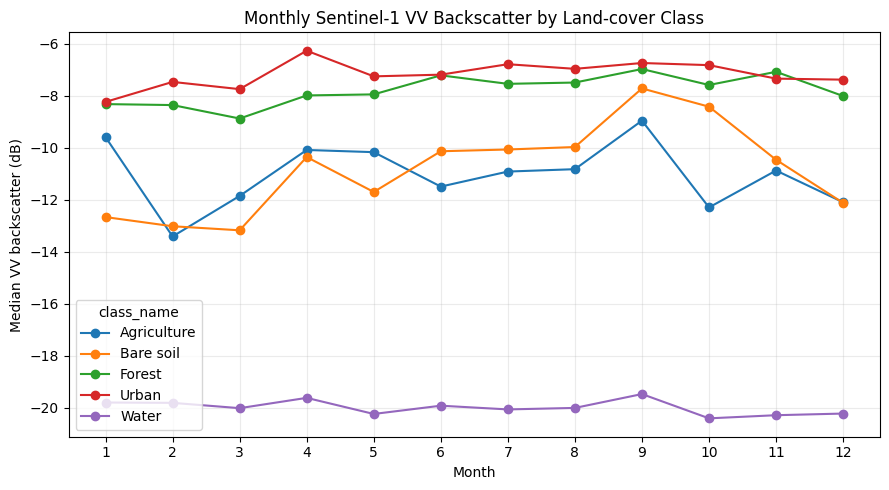

In [23]:
vv_summary = (
    temporal_df.groupby(['month', 'class_name'], as_index=False)['VV']
    .median()
)
vv_pivot = vv_summary.pivot(index='month', columns='class_name', values='VV')

ax = vv_pivot.plot(figsize=(9, 5), marker='o')
ax.set_title('Monthly Sentinel-1 VV Backscatter by Land-cover Class')
ax.set_xlabel('Month')
ax.set_ylabel('Median VV backscatter (dB)')
ax.set_xticks(range(1, 13))
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

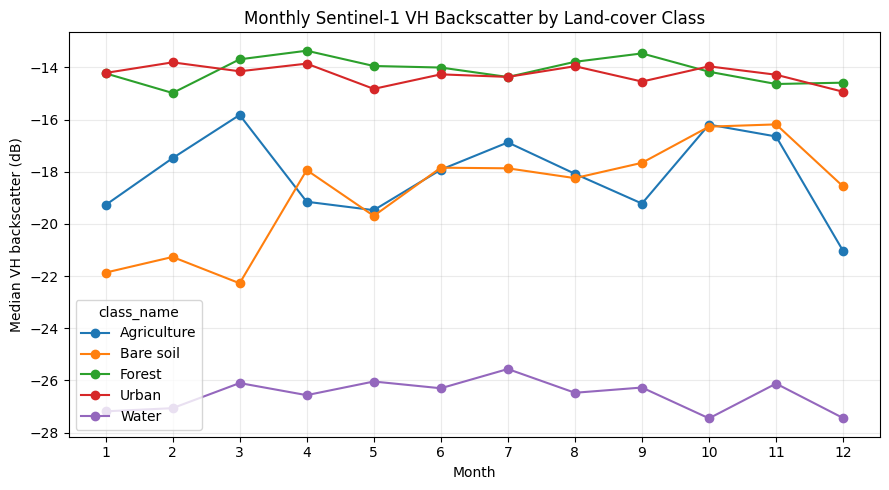

In [24]:
vh_summary = (
    temporal_df.groupby(['month', 'class_name'], as_index=False)['VH']
    .median()
)
vh_pivot = vh_summary.pivot(index='month', columns='class_name', values='VH')

ax = vh_pivot.plot(figsize=(9, 5), marker='o')
ax.set_title('Monthly Sentinel-1 VH Backscatter by Land-cover Class')
ax.set_xlabel('Month')
ax.set_ylabel('Median VH backscatter (dB)')
ax.set_xticks(range(1, 13))
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## Reading temporal signatures

พิจารณากราฟ VV และ VH แล้วตอบ

1. Water มี backscatter ต่ำสม่ำเสมอหรือไม่?
2. Urban มีค่าค่อนข้างสูงและคงที่หรือไม่?
3. Forest แสดง VH ต่างจาก Bare soil หรือไม่?
4. Agriculture มี temporal variability สูงกว่า class อื่นหรือไม่?
5. มีเดือนใดที่ Agriculture และ Forest เข้าใกล้กันมาก?
6. ถ้าใช้ Sentinel-1 เพียงเดือนเดียว มี class ใดที่อาจแยกยาก?

อย่าจำว่า class ใด “ต้อง” มีค่าเท่าใด

$$
\text{Backscatter}=\text{surface physics}+\text{moisture}+\text{structure}+\text{geometry}+\text{time}
$$

# Part 13 — Why agriculture benefits from temporal information

Agricultural surfaces เปลี่ยนอย่างรวดเร็วตาม

```text
land preparation → planting → growth → maturity → harvest → fallow
```

และได้รับผลจาก flooding, soil moisture, crop structure และ canopy development

ดังนั้นข้อมูลสำคัญอาจไม่ใช่เพียง $VV$ หรือ $VH$ ณ เวลาเดียว แต่เป็น

$$
VV(t)
$$

และ

$$
VH(t)
$$

นี่คือพื้นฐานของการนำ Sentinel-1 ไปทำ rice / crop mapping ในภายหลัง

# Part 14 — Build the 24-band Sentinel-1 feature stack

รวม monthly composites เป็น

$$
\mathbf{x}_{S1}=[VV_{Jan},VH_{Jan},VV_{Feb},VH_{Feb},\dots,VV_{Dec},VH_{Dec}]
$$

ดังนั้น

$$
p=24
$$

predictor variables

**Notebook 03 จะหยุดที่นี่** — ยังไม่ train Random Forest

In [25]:
s1_stack = monthly_images[0]
for image in monthly_images[1:]:
    s1_stack = s1_stack.addBands(image)

s1_stack = s1_stack.clip(study_area)

band_names = s1_stack.bandNames().getInfo()
print('Number of S1 temporal predictors:', len(band_names))
display(band_names)

Number of S1 temporal predictors: 24


['VV_Jan',
 'VH_Jan',
 'VV_Feb',
 'VH_Feb',
 'VV_Mar',
 'VH_Mar',
 'VV_Apr',
 'VH_Apr',
 'VV_May',
 'VH_May',
 'VV_Jun',
 'VH_Jun',
 'VV_Jul',
 'VH_Jul',
 'VV_Aug',
 'VH_Aug',
 'VV_Sep',
 'VH_Sep',
 'VV_Oct',
 'VH_Oct',
 'VV_Nov',
 'VH_Nov',
 'VV_Dec',
 'VH_Dec']

In [26]:
example_point = all_points.first()
example_values = (
    s1_stack.sample(
        region=ee.Feature(example_point).geometry(),
        scale=10,
        numPixels=1,
        geometries=False,
    ).first()
)

print('Example sample ID:', ee.Feature(example_point).get('sample_id').getInfo())

if example_values is not None:
    display(ee.Feature(example_values).toDictionary().getInfo())

Example sample ID: UR001


{'VH_Apr': -17.559321701791944,
 'VH_Aug': -18.02024063335395,
 'VH_Dec': -18.99815035749461,
 'VH_Feb': -19.077491839716462,
 'VH_Jan': -18.435701396403033,
 'VH_Jul': -18.667395444480295,
 'VH_Jun': -17.047534190712383,
 'VH_Mar': -17.290794830971276,
 'VH_May': -17.214334036107196,
 'VH_Nov': -18.005985050796802,
 'VH_Oct': -18.409979716450152,
 'VH_Sep': -20.097556570930884,
 'VV_Apr': -11.180668927305993,
 'VV_Aug': -11.917477604975172,
 'VV_Dec': -12.9401169003006,
 'VV_Feb': -11.671378924337425,
 'VV_Jan': -12.768133519976432,
 'VV_Jul': -10.956333767777476,
 'VV_Jun': -8.235765180999257,
 'VV_Mar': -12.764635831900609,
 'VV_May': -12.349151170566014,
 'VV_Nov': -10.445300819385775,
 'VV_Oct': -12.973036546232734,
 'VV_Sep': -11.95380716901161}

# Optional export — Sentinel-1 temporal feature stack

Notebook นี้ยังไม่มี classification map แต่สามารถ export 24-band stack ไปตรวจใน QGIS ได้

```text
VV_Jan, VH_Jan, ..., VV_Dec, VH_Dec
```

การ export นี้เป็น optional และสามารถข้ามได้ในชั้นเรียน

In [27]:
export_stack = False

if export_stack:
    task = ee.batch.Export.image.toDrive(
        image=s1_stack.toFloat(),
        description='PHS_S1_Monthly_VV_VH_Stack_2021',
        folder='GEE_LULC',
        fileNamePrefix='PHS_S1_Monthly_VV_VH_Stack_2021',
        region=study_area,
        scale=10,
        crs='EPSG:32647',
        maxPixels=1e13,
        fileFormat='GeoTIFF',
        formatOptions={'cloudOptimized': True},
    )
    task.start()
    print('Export started.')
    print(task.status())
else:
    print('Export skipped. Set export_stack = True if you want the GeoTIFF.')

Export skipped. Set export_stack = True if you want the GeoTIFF.


# Exercise — Interpret before classifying

เลือกอย่างน้อย 3 classes เช่น Water, Urban และ Agriculture แล้วตอบ

1. VV และ VH ของแต่ละ class แตกต่างกันอย่างไร?
2. Class ใดมี temporal variability สูง?
3. Class ใดค่อนข้าง stable ตลอดปี?
4. Single-month SAR image อาจทำให้ class ใดสับสนกัน?
5. Temporal information น่าจะช่วย class ใดมากที่สุด?
6. เพราะเหตุใด `Agriculture` จึงไม่ควรถูกตีความว่า `Rice` โดยอัตโนมัติ?

### Advanced question

หากรวม Ascending และ Descending โดยไม่ควบคุม geometry temporal variability ที่เห็นจะมาจาก land-cover change จริงทั้งหมดหรือไม่?

# Take-home messages

1. Sentinel-1 เป็น **active C-band SAR** ไม่ใช่ optical sensor
2. SAR วิเคราะห์ backscatter ไม่ใช่ spectral reflectance
3. `COPERNICUS/S1_GRD` ให้ VV/VH ใน dB
4. VV และ VH ตอบสนองต่อ scattering mechanisms ต่างกัน
5. Orbit geometry และ incidence angle มีผลต่อ backscatter
6. Speckle เป็นคุณสมบัติของ coherent SAR imaging
7. Monthly median ช่วยสร้าง temporal representation ที่เสถียรกว่าภาพเดี่ยว
8. Agriculture มีความสำคัญเชิง temporal เพราะสภาพพื้นผิวเปลี่ยนตาม crop cycle
9. Monthly VV/VH 12 เดือนสร้าง feature space จำนวน 24 predictors

## Next

**Notebook 04 — Sentinel-1 Multitemporal LULC Classification**

```text
24-band S1 feature stack
        +
same reference locations
        +
Random Forest
        +
same validation points
        ↓
5-class LULC classification
        ↓
Variable importance
        ↓
Accuracy assessment
```

# References and documentation

- Google Earth Engine — Sentinel-1 Algorithms  
  https://developers.google.com/earth-engine/guides/sentinel1

- Google Earth Engine — Sentinel-1 GRD Data Catalog  
  https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S1_GRD

- Google Earth Engine — Sentinel-1 SAR Basics  
  https://developers.google.com/earth-engine/tutorials/community/sar-basics

- Google Earth Engine — Sentinel-1 Change Detection Tutorials  
  https://developers.google.com/earth-engine/tutorials/community/detecting-changes-in-sentinel-1-imagery-pt-1

### Teaching note

Notebook นี้ตั้งใจแยก **sensor understanding** ออกจาก **machine-learning classification** การจำแนก Sentinel-1 จะเริ่มใน Notebook 04 หลังจากผู้เรียนเข้าใจ physical interpretation และ temporal behaviour ของ SAR แล้ว